In [2]:
import matplotlib.pyplot as plt
import numpy as np

g = 10

def a(p0, theta0, h, Nit, m, l):
  p = np.zeros((Nit))
  theta = np.zeros((Nit))

  p[0] = p0
  theta[0] = theta0

  for i in range(Nit-1):
    k1theta = p[i]*h/(m*l*l)
    k1p = -m*g*l*np.sin(theta[i])*h

    theta_aux = theta[i] + k1theta/2
    p_aux = p[i] + k1p/2

    k2theta = p_aux*h/(m*l*l)
    k2p = -m*g*l*np.sin(theta_aux)*h

    p[i+1] = p[i] + k2p
    theta[i+1] = theta[i] + k2theta
    
    if theta[i+1]>np.pi: theta[i+1] -= 2*np.pi
    elif theta[i+1] <-np.pi: theta[i+1] += 2*np.pi
    else: pass

  return p, theta



T_0: 1.404962946 s
theta_max: 0.644 rad
Periodo: 1.441 s


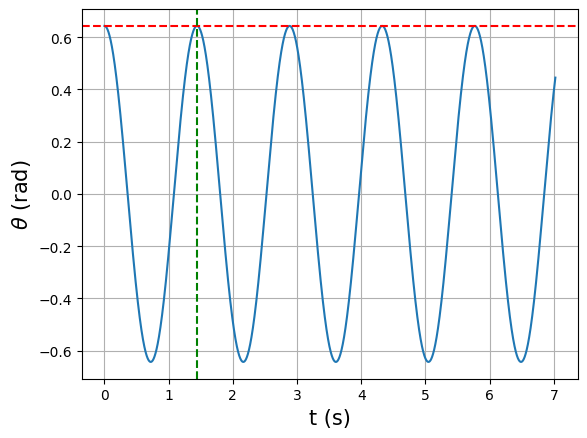

In [18]:
m=0.1 # in kg
l=0.5 # in m
E1 = 0.1 #Joules
#Supondo que a particula parta do repouso, podemos calcular o valor
#de theta_max diretamente, e que sera justamente a posicao inicial
#Isso pois E = mgl(1-cos(theta_max)) => theta_max = arccos(1-E/(mgl))
theta01 = np.arccos(1-E1/(m*g*l)) # in rad
p0=0. # in kg m^2/s

#Ja o periodo eh dado por T_0 = 2pi*sqrt(l/g)

T0 = 2*np.pi*np.sqrt(l/g)

print(f"T_0: {T0:.9f} s")
print(f"theta_max: {theta0:.3f} rad")

#Escolhendo um passo de tempo pequeno o suficiente para que a simulacao seja precisa
h=2e-4 # in s
Tf=5*T0 # in s

t = np.arange(0, Tf+h, h)
Nit = len(t)

P1, THETA1 = a(p0, theta01, h, Nit, m, l)

for i in range(len(t)):
    #Contamos o periodo a partir do instante em que o pêndulo passa pela posição inicial (theta0) e o proximo maximo
    #e o tempo é maior que T0 (para que os passos iniciais nao sejam considerados na tolerancia de ponto flutuante)
    if np.isclose(THETA1[i], theta01, atol = 1e-6) and t[i]>T0:
        T1 = t[i]
        print(f"Periodo: {T1:.3f} s")
        break

plt.plot(t, THETA1)
plt.axhline(theta01, color='red', linestyle='--')
plt.axvline(T1, color='green', linestyle='--')
plt.xlabel('t (s)', fontsize = 15)
plt.ylabel(r'$\theta$ (rad)', fontsize = 15)
plt.grid(True)

theta_max: 2.214 rad
Periodo: 2.017 s


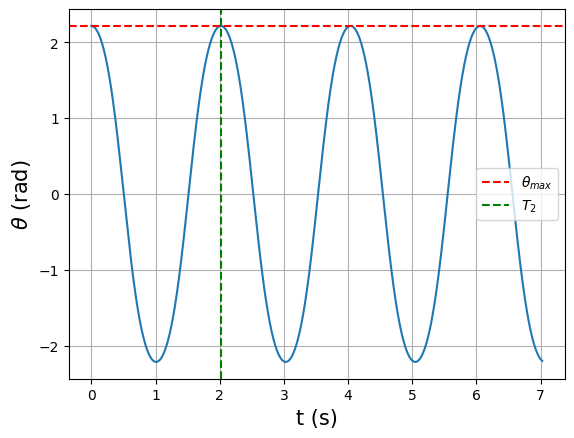

In [22]:
E2 = 0.8 #Joules
#Supondo que a particula parta do repouso, podemos calcular o valor
#de theta_max diretamente, e que sera justamente a posicao inicial
#Isso pois E = mgl(1-cos(theta_max)) => theta_max = arccos(1-E/(mgl))
theta02 = np.arccos(1-E2/(m*g*l)) # in rad

print(f"theta_max: {theta02:.3f} rad")

#Escolhendo um passo de tempo pequeno o suficiente para que a simulacao seja precisa
h=2e-4 # in s
Tf=5*T0 # in s

t = np.arange(0, Tf+h, h)
Nit = len(t)

P2, THETA2 = a(p0, theta02, h, Nit, m, l)

for i in range(len(t)):
    #Contamos o periodo a partir do instante em que o pêndulo passa pela posição inicial (theta0) e o proximo maximo
    #e o tempo é maior que T0 (para que os passos iniciais nao sejam considerados na tolerancia de ponto flutuante)
    if np.isclose(THETA2[i], theta02, atol = 1e-6) and t[i]>T0:
        T2 = t[i]
        print(f"Periodo: {T2:.3f} s")
        break

plt.plot(t, THETA2)
plt.axhline(theta02, color='red', linestyle='--', label = r'$\theta_{max}$')
plt.axvline(T2, color='green', linestyle='--', label = r'$T_2$')
plt.xlabel('t (s)', fontsize = 15)
plt.ylabel(r'$\theta$ (rad)', fontsize = 15)
plt.grid(True)
plt.legend()